In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
from scipy.special import legendre
from scipy.stats import norm
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sys.path.insert(1, '../../scripts')
import CMBanom

In [2]:
# Parameters
Nsims         = 100000
index_Hayley  = 2
index_Planck  = 4

# Anomaly-specific params
mu_index      = 14
R_index    = 27

In [3]:
# Directories
stats_dir = "../../data/stats/"

# Planck maps  
labels_Planck = [ r"$70\, \mathrm{GHz}$",  r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$", r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$"]
colors_Planck = [  "tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [        "-",    "-",     "-",     "-",      "--",      "--",     "--",     "--"]
color_qml     = "green"
label_qml     = r"$\mathrm{Public\ QML-}C_\ell$"
index_Hayley  = 2
index_Planck  = 4
Nmaps = len(labels_Planck)

# Masks
names_mask       = [              "fullsky",                "stdmask",                  "commask"]
names_mask_table = [             "full sky",              "std. mask",                "com. mask"]
labels_mask      = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask      = [             "tab:blue",                   "navy",                "firebrick"]
Nmasks = len(labels_mask)

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':23})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  23}

In [5]:
# Load stats
Smu_sims = np.array([np.loadtxt(stats_dir+f"Smu_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
Smu_real = np.load(stats_dir+"Smu_real.npy")
Smu_PQML = np.load(stats_dir+"Smu_real_QML.npy")

R_sims = np.array([np.loadtxt(stats_dir+f"R_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
R_real = np.load(stats_dir+"R_real.npy")
R_PQML = np.load(stats_dir+"R_real_QML.npy")

SQO_sims = np.array([np.loadtxt(stats_dir+f"SQO_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
SQO_real = np.load(stats_dir+"SQO_real.npy")

sigma16_sims = np.array([np.loadtxt(stats_dir+f"sigma16_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
sigma16_real = np.load(stats_dir+"sigma16_real.npy")

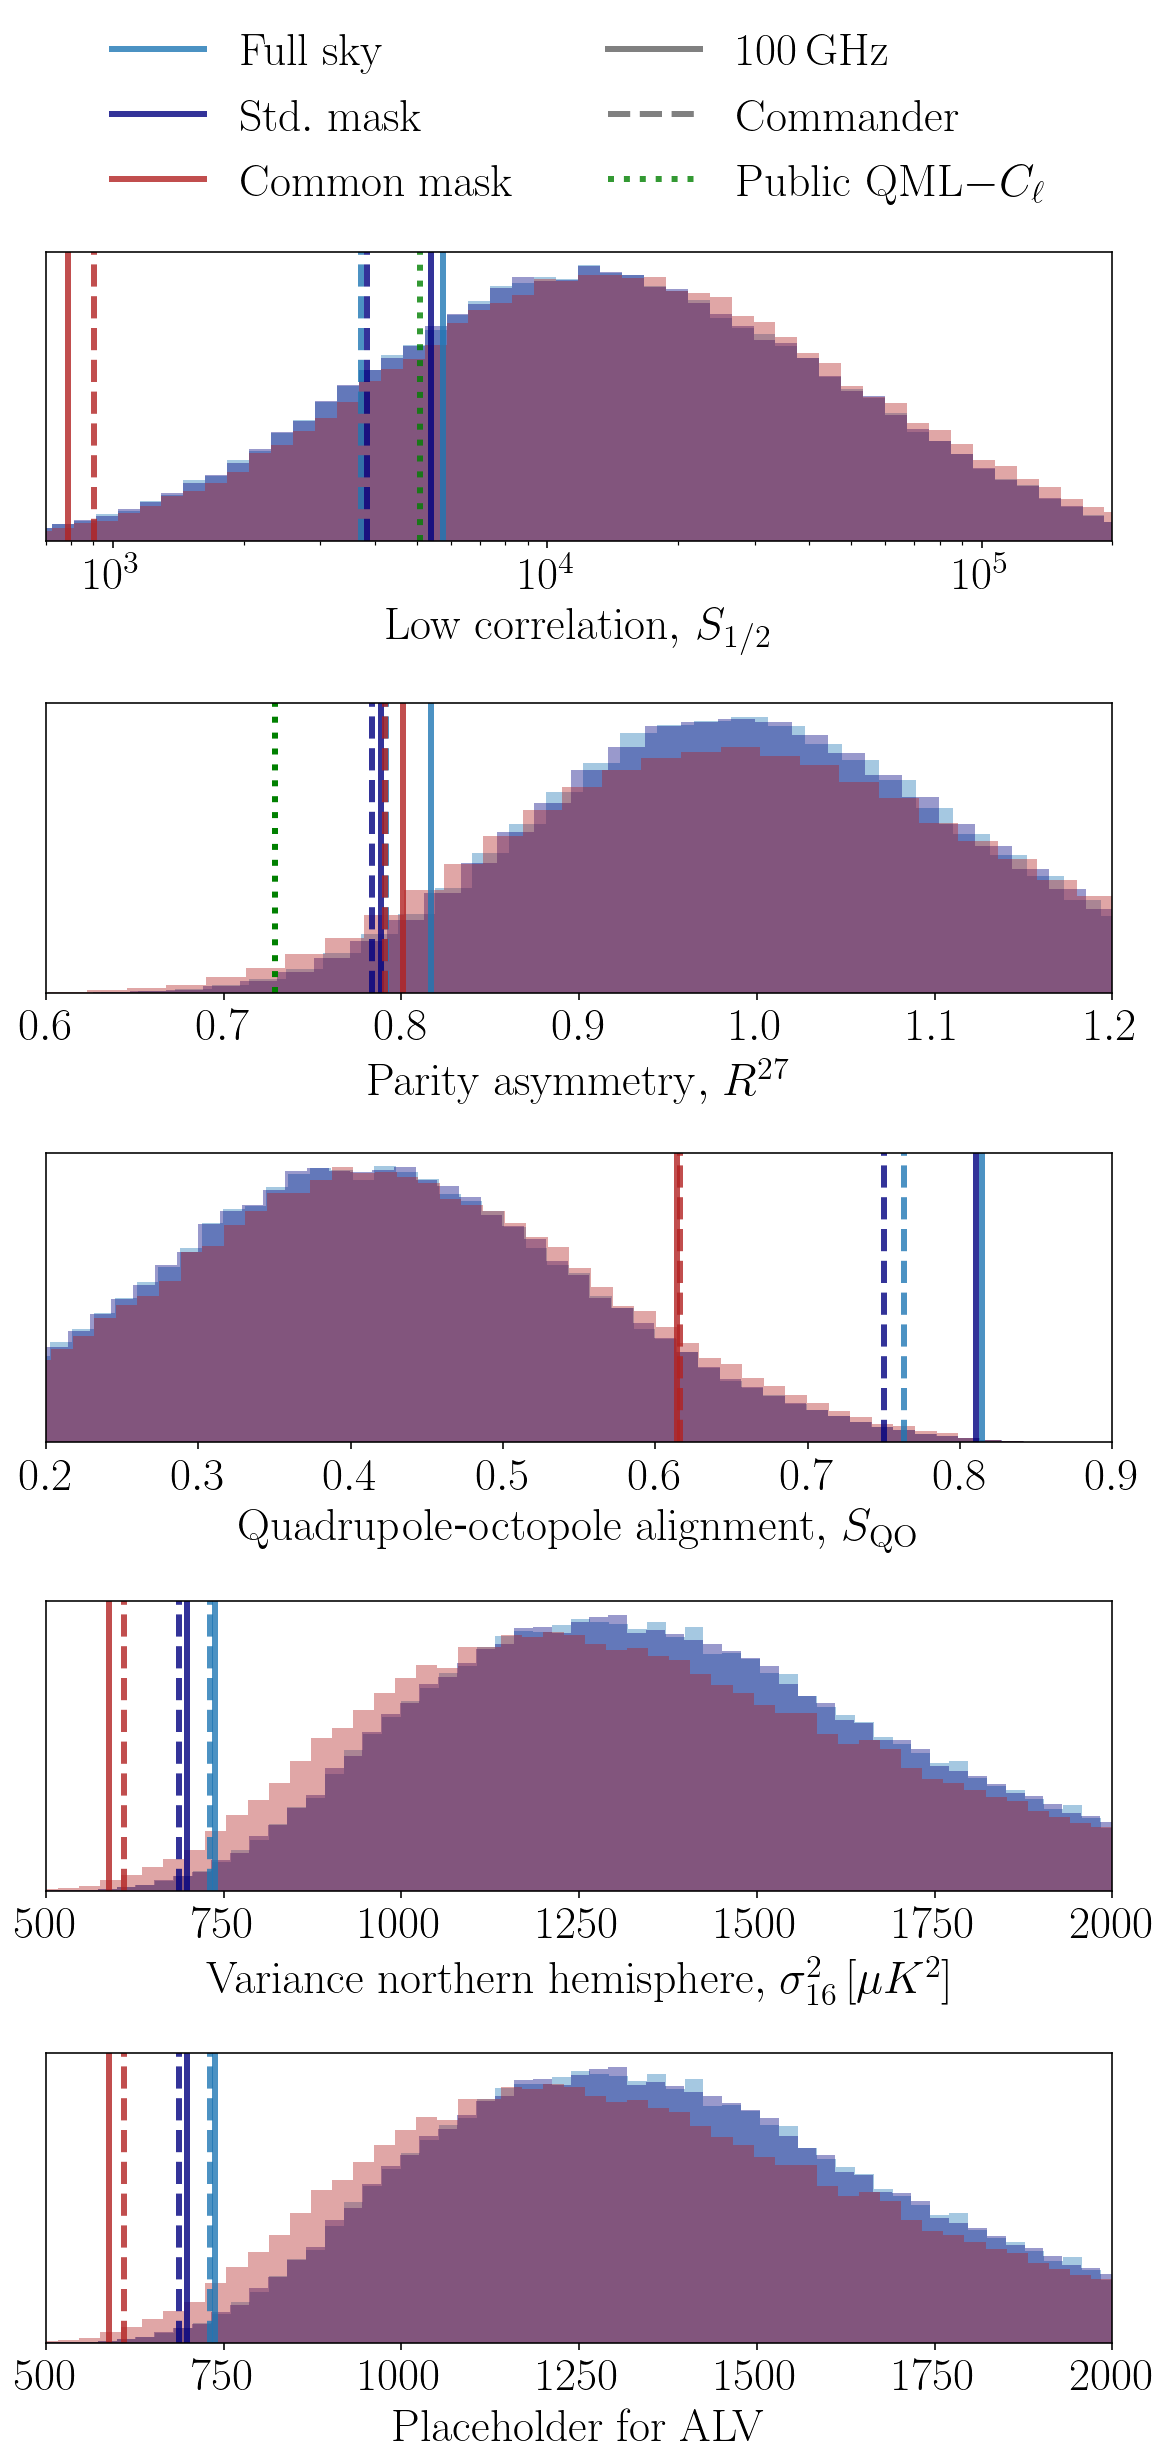

In [6]:
fig, axs = plt.subplots(5, 1, figsize=(8, 17), constrained_layout=True, gridspec_kw={'hspace': 0.1})

# S_1/2
bins = 10**np.linspace(2, 7, 100)
for m in range(Nmasks):
    axs[0].hist(Smu_sims[m][mu_index], bins=bins, color=colors_mask[m], alpha=0.4)
    axs[0].axvline(Smu_real[m][index_Hayley][mu_index], color=colors_mask[m], lw=3, alpha=0.8, ls="-", label=labels_mask[m])
    axs[0].axvline(Smu_real[m][index_Planck][mu_index], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
axs[0].plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
axs[0].plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
axs[0].axvline(Smu_PQML[mu_index], color=color_qml, lw=3, alpha=0.8, ls=":", label=label_qml)

axs[0].set_xlim(7e2, 2e5)
axs[0].set_xscale("log")
axs[0].set_xlabel(r"$\mathrm{Low\ correlation,\ } S_{1/2}$")
axs[0].tick_params(axis='y', which='both', left=False, labelleft=False)

# R^27
bins = 60 
for m in range(Nmasks):
    axs[1].hist(R_sims[m].T[27], bins=bins, alpha=0.4, density=True, color=colors_mask[m])
    axs[1].axvline(R_real[m][index_Planck][27], color=colors_mask[m], alpha=0.8, lw=3, ls="-", label=labels_mask[m])
    axs[1].axvline(R_real[m][index_Hayley][27], color=colors_mask[m], alpha=0.8, lw=3, ls="--")
axs[1].axvline(R_PQML[27], color=color_qml, label=label_qml, ls=":", lw=3)
axs[1].set_xlim(0.6, 1.2)
axs[1].set_xlabel(r"$\mathrm{Parity\ asymmetry,}\ R^{27}$")
axs[1].tick_params(axis='y', which='both', left=False, labelleft=False)

# S_QO
axs[2].plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
axs[2].plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    axs[2].hist(SQO_sims[m], bins=bins, color=colors_mask[m], alpha=0.4)
    axs[2].axvline(SQO_real[m][index_Hayley], color=colors_mask[m], lw=3, alpha=0.8, ls="-", label=labels_mask[m])
    axs[2].axvline(SQO_real[m][index_Planck], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
axs[2].set_xlim(0.2, 0.9)
axs[2].set_xlabel(r"$\mathrm{Quadrupole}$-$\mathrm{octopole\ alignment,}\ S_\mathrm{QO}$")
axs[2].tick_params(axis='y', which='both', left=False, labelleft=False)

# sigma^2_16
bins = 150
axs[3].plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
axs[3].plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    axs[3].hist(sigma16_sims[m], bins=bins, alpha=0.4, density=True, color=colors_mask[m])
    axs[3].axvline(sigma16_real[m][index_Hayley], color=colors_mask[m], alpha=0.8, lw=3, ls="-", label=labels_mask[m])
    axs[3].axvline(sigma16_real[m][index_Planck], color=colors_mask[m], alpha=0.8, lw=3, ls="--")
axs[3].set_xlim(500, 2000)
axs[3].set_xlabel(r"$\mathrm{Variance\ northern\ hemisphere,}\ \sigma^2_{16}\, [\mu K^2]$")
axs[3].tick_params(axis='y', which='both', left=False, labelleft=False)

# A_LV
axs[4].plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
axs[4].plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    axs[4].hist(sigma16_sims[m], bins=bins, alpha=0.4, density=True, color=colors_mask[m])
    axs[4].axvline(sigma16_real[m][index_Hayley], color=colors_mask[m], alpha=0.8, lw=3, ls="-", label=labels_mask[m])
    axs[4].axvline(sigma16_real[m][index_Planck], color=colors_mask[m], alpha=0.8, lw=3, ls="--")
axs[4].set_xlim(500, 2000)
axs[4].set_xlabel(r"$\mathrm{Placeholder\ for\ ALV}$")
axs[4].tick_params(axis='y', which='both', left=False, labelleft=False)

# Add legend to the top plot
axs[0].legend(loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.9))

plt.savefig("anomaly_summary.pdf", format="PDF", bbox_inches="tight")
plt.show()

/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


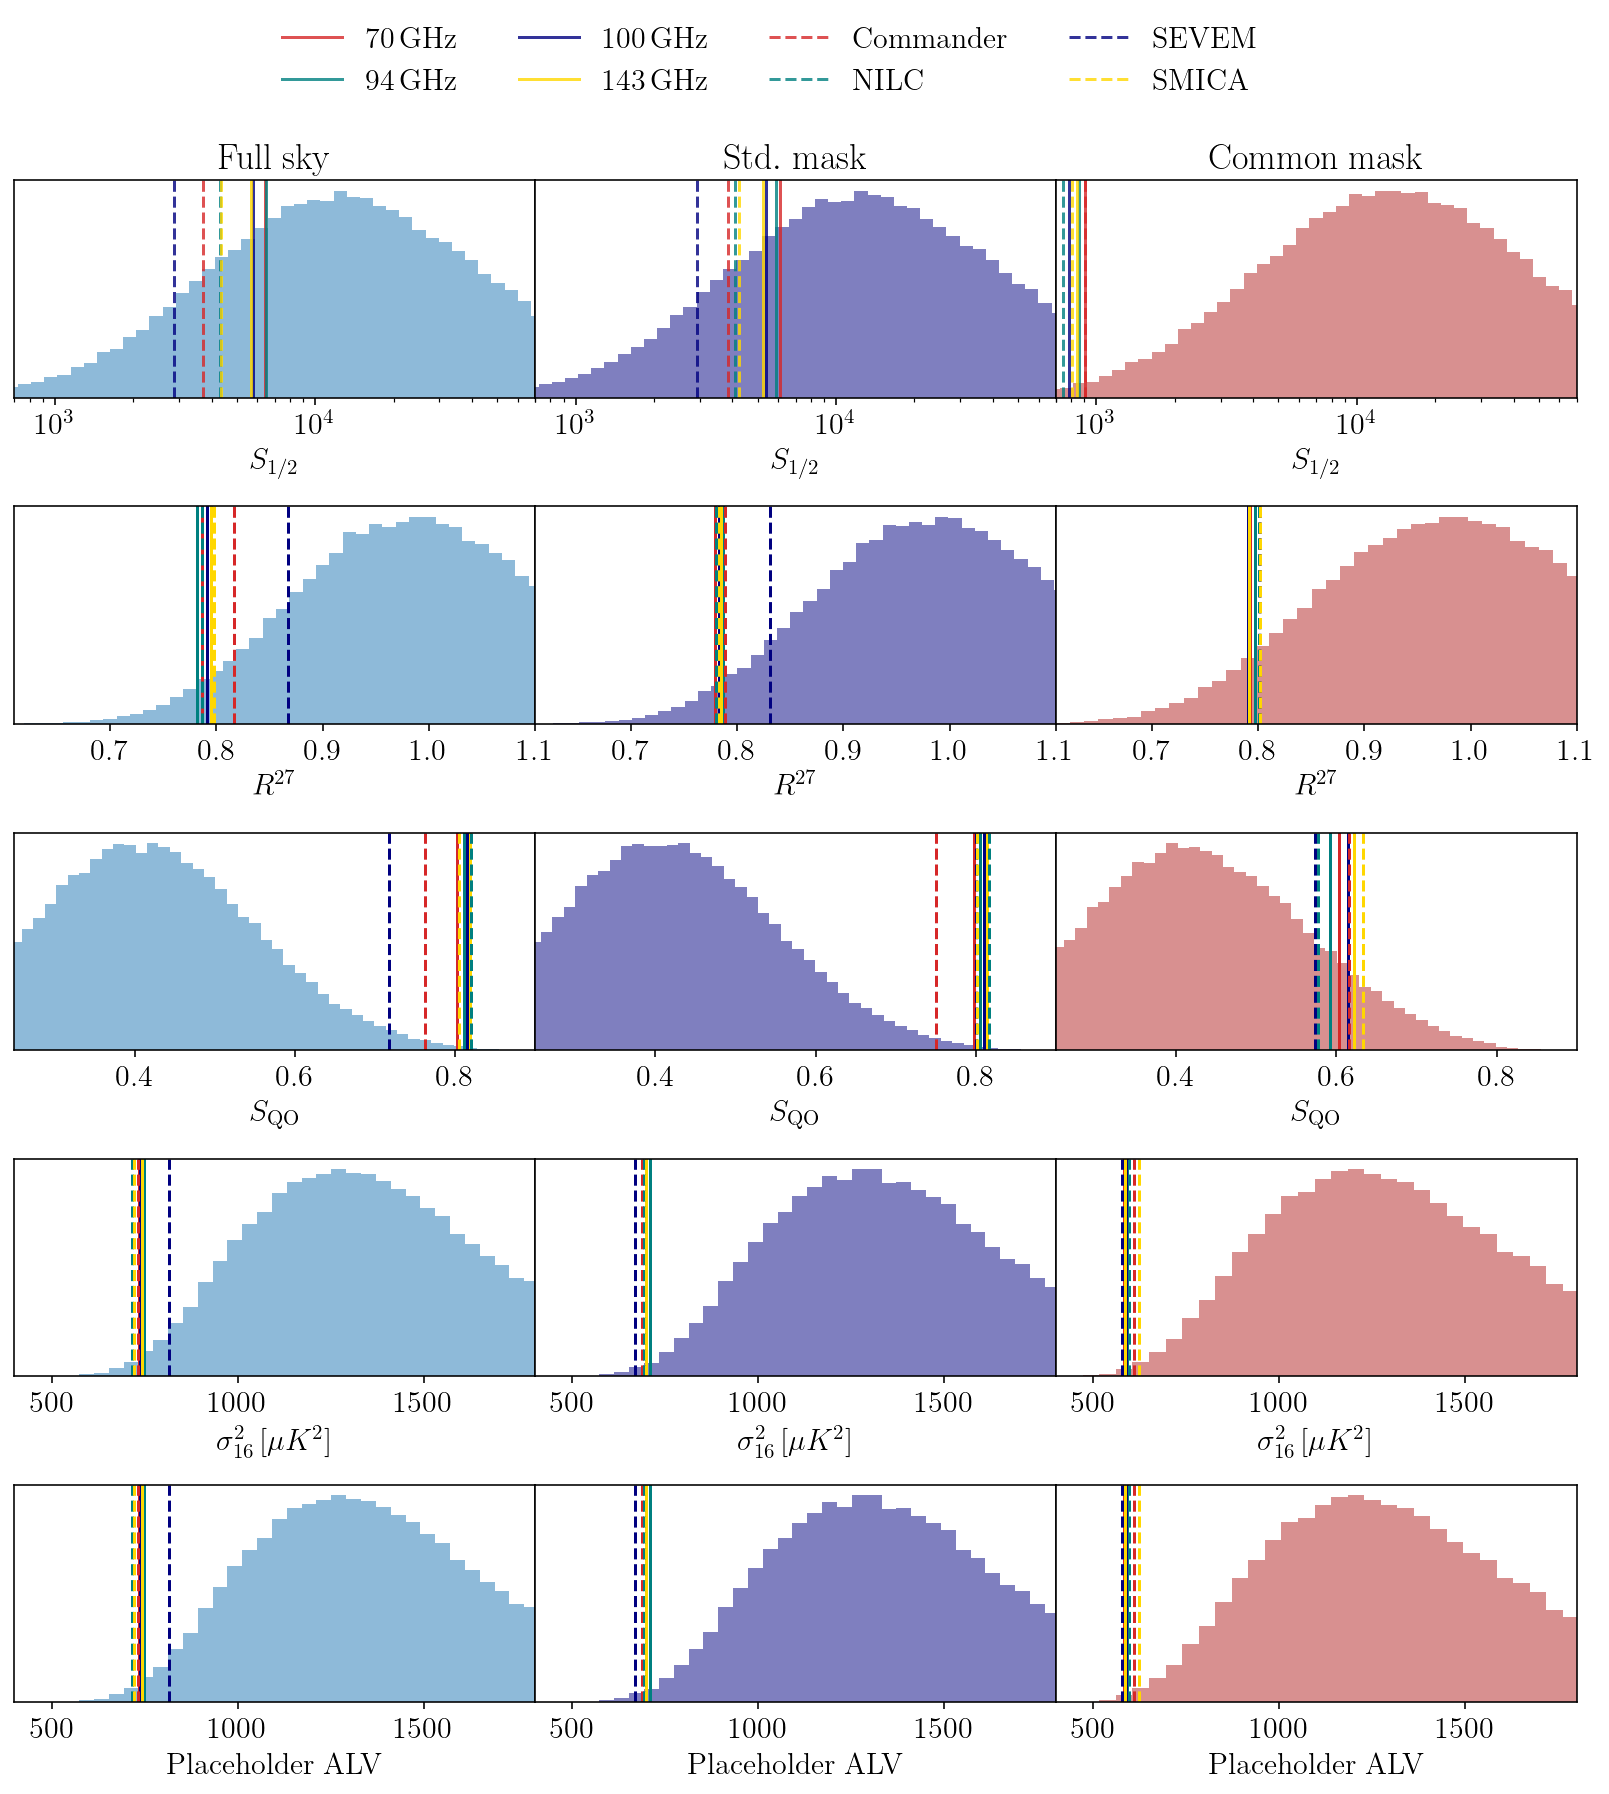

In [7]:
# Font
plt.rc('font',**{'family':'Helvetica','size':15})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  15}

fig, axs = plt.subplots(5, Nmasks, figsize=(14, 14), sharey=False, gridspec_kw={'wspace': 0, 'hspace': 0.5})

# S_1/2
bins = 10**np.linspace(2, 7, 100)
for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[0, m].axvline(Smu_real[m][n][mu_index], color=colors_Planck[n], ls=lss_Planck[n], label=labels_Planck[n], alpha=0.8)
    axs[0, m].hist(Smu_sims[m][mu_index], bins=bins, color=colors_mask[m], alpha=0.5)
    axs[0, m].set_xscale("log")
    axs[0, m].set_xlim(7e2, 7e4)
    axs[0, m].tick_params(axis='y', which='both', left=False, labelleft=False) 
    axs[0, m].set_xlabel(r"$S_{1/2}$")
    axs[0, m].set_title(labels_mask[m])

# R^27
for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[1, m].axvline(R_real[m][n][R_index], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    axs[1, m].hist(R_sims[m].T[27], bins=100, alpha=0.5, color=colors_mask[m])
    axs[1, m].set_xlim(0.61, 1.1)
    axs[1, m].tick_params(axis='y', which='both', left=False, labelleft=False) 
    axs[1, m].set_xlabel(r"$R^{27}$")

# S_QO
bins = 60
for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[2, m].axvline(SQO_real[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    axs[2, m].hist(SQO_sims[m], bins=bins, alpha=0.5, color=colors_mask[m])
    axs[2, m].set_xlim(0.25, 0.9)
    axs[2, m].tick_params(axis='y', which='both', left=False, labelleft=False) 
    axs[2, m].set_xlabel(r"$S_\mathrm{QO}$")

# sigma^2_16
for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[3, m].axvline(sigma16_real[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    axs[3, m].hist(sigma16_sims[m], bins=100, alpha=0.5, color=colors_mask[m])
    axs[3, m].set_xlim(400, 1800)
    axs[3, m].tick_params(axis='y', which='both', left=False, labelleft=False) 
    axs[3, m].set_xlabel(r"$\sigma^2_{16}\, [\mu K^2]$")

# A_LV
for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[4, m].axvline(sigma16_real[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    axs[4, m].hist(sigma16_sims[m], bins=100, alpha=0.5, color=colors_mask[m])
    axs[4, m].set_xlim(400, 1800)
    axs[4, m].tick_params(axis='y', which='both', left=False, labelleft=False) 
    axs[4, m].set_xlabel(r"$\mathrm{Placeholder\ ALV}$")

# # Add legend
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, .97), frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("anomaly_summary_all.pdf", format="PDF", bbox_inches="tight")
plt.show()

# Compute p-values and print table

In [8]:
p_Smu_real = np.array([[CMBanom.pval_lower(Smu_real[m][n][mu_index], Smu_sims[m][mu_index]) for n in range(Nmaps)] for m in range(Nmasks)])
p_Smu_PQML = np.array( [CMBanom.pval_lower(Smu_PQML[mu_index], Smu_sims[m][mu_index]) for m in range(Nmasks)])

p_R_real = np.array([[CMBanom.pval_lower(R_real[m][n][R_index], R_sims[m].T[R_index]) for n in range(Nmaps)] for m in range(Nmasks)])
p_R_PQML = np.array( [CMBanom.pval_lower(R_PQML[R_index], R_sims[m].T[R_index]) for m in range(Nmasks)])

p_SQO_real = np.array([[CMBanom.pval_higher(SQO_real[m][n], SQO_sims[m]) for n in range(Nmaps)] for m in range(Nmasks)])

p_sigma16_real = np.array([[CMBanom.pval_lower(sigma16_real[m][n], sigma16_sims[m]) for n in range(Nmaps)] for m in range(Nmasks)])


In [9]:
print("Table 1: p-values")
print("-----------------")
print("    \hline")
for m in range(Nmasks):
    if m==1: print(f"    $S_{{1/2}}$       &{names_mask_table[m]}: ", end="")
    else:    print(f"                    &{names_mask_table[m]}: ", end="")
    for n in range(Nmaps):
        print(f"&{100*p_Smu_real[m][n]:.2f} ", end="")
    print("\\\\")
print("    \hline")
for m in range(Nmasks):
    if m==1: print(f"    $R^{{27}}$        &{names_mask_table[m]}: ", end="")
    else:    print(f"                    &{names_mask_table[m]}: ", end="")
    for n in range(Nmaps):
        print(f"&{100*p_R_real[m][n]:.2f} ", end="")
    print("\\\\")
print("    \hline")
for m in range(Nmasks):
    if m==1: print(f"    $S_{{QO}}$        &{names_mask_table[m]}: ", end="")
    else:    print(f"                    &{names_mask_table[m]}: ", end="")
    for n in range(Nmaps):
        print(f"&{100*p_SQO_real[m][n]:.2f} ", end="")
    print("\\\\")
print("    \hline")
for m in range(Nmasks):
    if m==1: print(f"    $\sigma_{{16}}^2$ &{names_mask_table[m]}: ", end="")
    else:    print(f"                    &{names_mask_table[m]}: ", end="")
    for n in range(Nmaps):
        print(f"&{100*p_sigma16_real[m][n]:.2f} ", end="")
    print("\\\\")
print("    \hline")

Table 1: p-values
-----------------
    \hline
                    &full sky: &27.92 &28.14 &25.06 &24.73 &15.07 &18.24 &10.42 &18.40 \\
    $S_{1/2}$       &std. mask: &26.55 &25.75 &23.30 &22.67 &15.73 &16.99 &10.69 &17.76 \\
                    &com. mask: &1.00 &0.88 &0.72 &0.86 &0.99 &0.62 &0.46 &0.76 \\
    \hline
                    &full sky: &2.79 &2.52 &3.15 &3.44 &5.36 &2.81 &12.77 &3.63 \\
    $R^{27}$        &std. mask: &2.39 &2.81 &2.64 &2.73 &2.96 &2.44 &6.95 &2.64 \\
                    &com. mask: &5.09 &5.55 &4.93 &5.03 &5.90 &5.87 &6.01 &5.96 \\
    \hline
                    &full sky: &0.11 &0.08 &0.06 &0.05 &0.46 &0.04 &1.35 &0.10 \\
    $S_{QO}$        &std. mask: &0.14 &0.10 &0.08 &0.07 &0.63 &0.06 &0.13 &0.11 \\
                    &com. mask: &10.12 &11.44 &8.74 &7.90 &8.56 &13.72 &14.19 &6.81 \\
    \hline
                    &full sky: &0.67 &0.80 &0.69 &0.73 &0.61 &0.48 &2.05 &0.53 \\
    $\sigma_{16}^2$ &std. mask: &0.38 &0.46 &0.38 &0.38 &0.30 &0.34 &0.21

In [10]:
print("Table 2: stats values")
print("-----------------")
print("    \hline")
for m in range(Nmasks):
    if m==1: print(f"    $S_{{1/2}}$       &{names_mask_table[m]}: ", end="")
    else:    print(f"                    &{names_mask_table[m]}: ", end="")
    for n in range(Nmaps):
        print(f"&{Smu_real[m][n][mu_index]:.0f} ", end="")
    print("\\\\")
print("    \hline")
for m in range(Nmasks):
    if m==1: print(f"    $R^{{27}}$        &{names_mask_table[m]}: ", end="")
    else:    print(f"                    &{names_mask_table[m]}: ", end="")
    for n in range(Nmaps):
        print(f"&{R_real[m][n][R_index]:.2f} ", end="")
    print("\\\\")
print("    \hline")
for m in range(Nmasks):
    if m==1: print(f"    $S_{{QO}}$        &{names_mask_table[m]}: ", end="")
    else:    print(f"                    &{names_mask_table[m]}: ", end="")
    for n in range(Nmaps):
        print(f"&{SQO_real[m][n]:.2f} ", end="")
    print("\\\\")
print("    \hline")
for m in range(Nmasks):
    if m==1: print(f"    $\sigma_{{16}}^2$ &{names_mask_table[m]}: ", end="")
    else:    print(f"                    &{names_mask_table[m]}: ", end="")
    for n in range(Nmaps):
        print(f"&{sigma16_real[m][n]:.0f} ", end="")
    print("\\\\")
print("    \hline")

Table 2: stats values
-----------------
    \hline
                    &full sky: &6404 &6456 &5761 &5693 &3726 &4324 &2861 &4358 \\
    $S_{1/2}$       &std. mask: &6098 &5912 &5380 &5245 &3847 &4086 &2915 &4238 \\
                    &com. mask: &904 &859 &788 &846 &901 &745 &661 &808 \\
    \hline
                    &full sky: &0.79 &0.78 &0.79 &0.80 &0.82 &0.79 &0.87 &0.80 \\
    $R^{27}$        &std. mask: &0.78 &0.79 &0.78 &0.78 &0.79 &0.78 &0.83 &0.78 \\
                    &com. mask: &0.79 &0.80 &0.79 &0.79 &0.80 &0.80 &0.80 &0.80 \\
    \hline
                    &full sky: &0.80 &0.81 &0.81 &0.82 &0.76 &0.82 &0.72 &0.80 \\
    $S_{QO}$        &std. mask: &0.80 &0.81 &0.81 &0.81 &0.75 &0.82 &0.80 &0.80 \\
                    &com. mask: &0.60 &0.59 &0.61 &0.62 &0.62 &0.58 &0.57 &0.63 \\
    \hline
                    &full sky: &736 &749 &738 &742 &731 &716 &816 &721 \\
    $\sigma_{16}^2$ &std. mask: &699 &709 &699 &697 &687 &692 &668 &699 \\
                    &com. mask:

# Compute $\sigma$ for Gaussian distribution for $p$-values

In [11]:
def p_value_to_sigma(p_value):
    sigma = norm.ppf(1 - p_value/2.)
    return sigma

In [33]:
p_value_to_sigma(0.0004)

3.540083799206175

array([0.0239 , 0.0281 , 0.0264 , 0.02727, 0.02959, 0.02436, 0.06952,
       0.02644])